# Logistic Regression on Madden Data

This notebook provides a structured demonstration of applying Logistic Regression to a real-world classification problem, using data from Madden NFL 2024. The primary goal is to showcase the essential steps of a machine learning workflow and how to interpret the probabilistic output of this powerful model.

---

## Dataset Overview

The dataset used is **madden.csv**, which contains various physical and statistical attributes for NFL players. For this analysis, we focus on classifying players into two distinct offensive categories based on just two physical features:

- **Features ($X$):** Height (in inches) and Weight (in lbs).  
- **Target ($Y$):** Binary classification of Wide Receiver (WR) vs. Halfback (HB).

---

## Methodology

The solution adheres to industry-standard practices to build a robust and well-generalized classification model.

### **1. Data Preparation and Splitting**

- The raw data is filtered to include only WRs and HBs, and a binary target label is created.  
- The feature data ($X$) and label data ($Y$) are separated.  
- A train-test split is performed to divide the data into training and independent testing sets, which is crucial for evaluating the model's true performance on unseen data.

### **2. Feature Standardization (`standardize_vectors`)**

Standardization (Z-score normalization) is applied to the features. This step transforms the data such that it has:

- Mean of \(0\)  
- Standard deviation of \(1\)

**Crucially:**  
The statistics (\(\mu\) and \(\sigma\)) are calculated **only from the training set** and then applied to both the training and testing sets.  
This prevents data leakage and ensures a fair evaluation.

### **3. Model Application**

- The Logistic Regression model is instantiated and trained (`model.fit`) using the standardized training features.

### **4. Visualization and Evaluation**

- The trained model's performance is quantified using classification accuracy on both the training and testing sets.  
- The final output is a visualization that plots the raw (unscaled) player data alongside the model's decision boundary and its probabilistic confidence gradient.

---

## Analyzing the Results and Plots

The final plots are analyzed to extract comprehensive insights into the model's performance and classification logic.

### **Decision Boundary**

- The straight dashed line represents the \(P(\text{WR}=1) = 0.5\) boundary.  
- Players falling on one side are classified as WR, while those on the other are classified as HB.

### **Probabilistic Confidence**

The color gradient (from red to blue) shows the model's confidence:

- **Deep red:** High confidence in a WR classification (\(P \approx 1.0\))  
- **Deep blue:** High confidence in an HB classification (\(P \approx 0.0\))  
- **Neutral/purple region:** Low confidence (\(P \approx 0.5\)), representing ambiguous samples where Height and Weight are not strongly predictive

### **Generalization**

By comparing the **Training Data Fit** plot with the **Testing Data Generalization** plot, we assess how well the model performs on new, unseen data—an essential indicator for avoiding overfitting.

---

Standardizing features...
Training Logistic Regression Model on scaled features...

--- Model Performance ---
Training Accuracy: 0.88
Testing Accuracy: 0.92


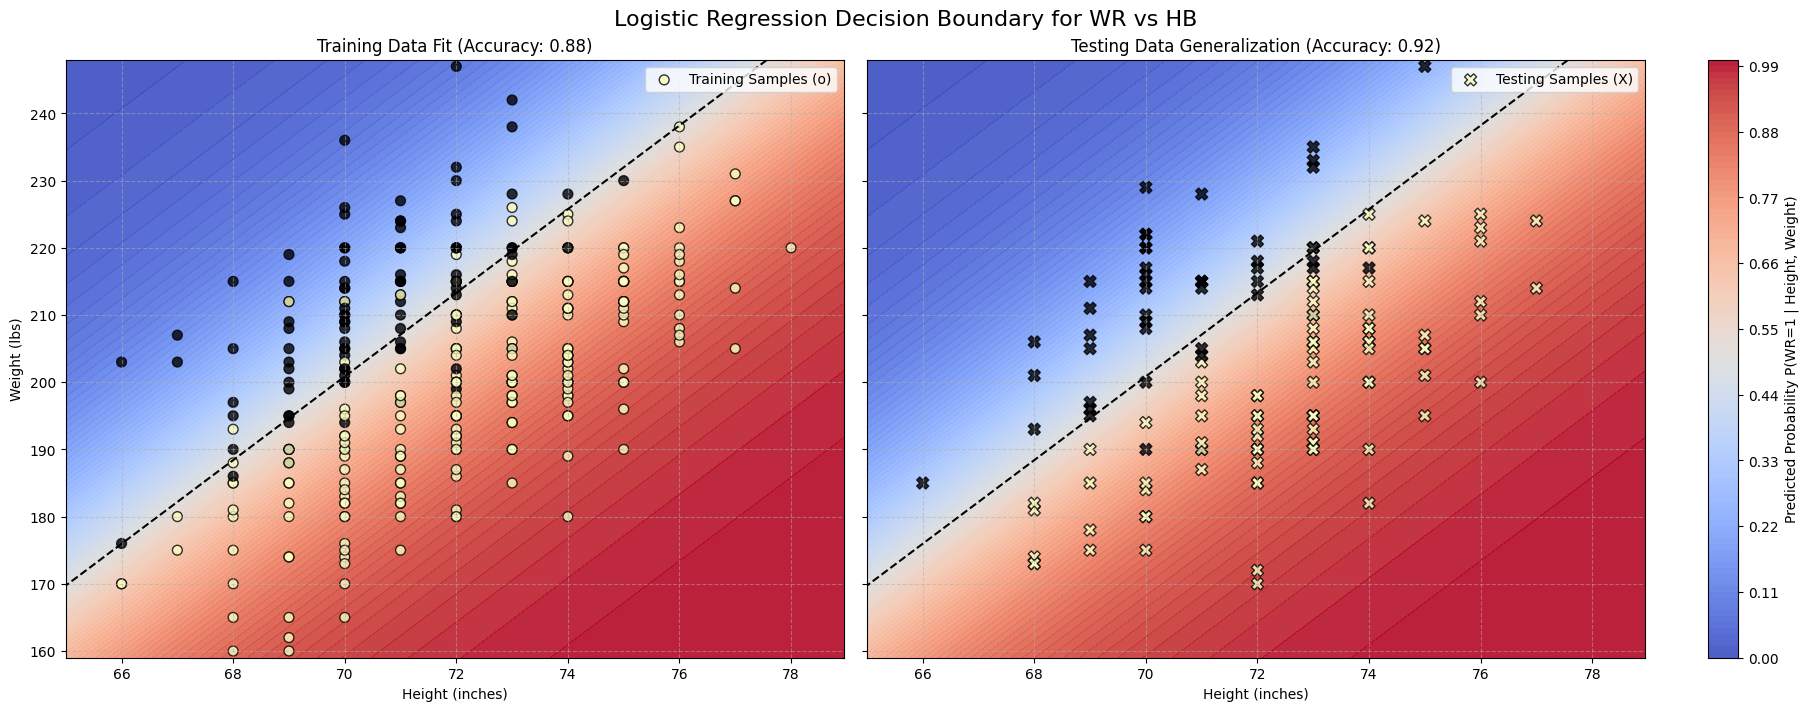

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ml import LogisticRegression
from ml import train_test_split_arrays
from ml import classification_accuracy
from ml import standardize_vectors

# --- Configuration ---
FILE_PATH = 'madden.csv'
TRAIN_RATIO = 0.7
RANDOM_SEED = 42
LR_PARAMS = {'learning_rate': 0.01, 'n_iterations': 1000}

# --- Data Loading ---
def load_and_prepare_data(filepath: str) -> tuple:
    """Loads, processes, removes outliers, and splits the data for WR vs HB classification."""
    df = pd.read_csv(filepath)

    # Remove outliers: drop anyone with height < 50 inches OR weight < 50 lbs
    df = df[(df['Height'] >= 50) & (df['Weight'] >= 50)]

    # Create binary target: 1 if WR, 0 if HB
    df = df[df['Position'].isin(['WR', 'HB'])]   # keep only WR and HB
    df['IsWR'] = df['Position'].apply(lambda p: 1 if p == 'WR' else 0)

    # Features and labels
    X = df[['Height', 'Weight']].values.astype(float)
    y = df['IsWR'].values

    # Train/test split
    X_train, y_train, X_test, y_test = train_test_split_arrays(
        X, y, train_ratio=TRAIN_RATIO, seed=RANDOM_SEED
    )
    return X, y, X_train, y_train, X_test, y_test

# --- Visualization ---
def visualize_decision_boundary(model: LogisticRegression, X: np.ndarray, 
                                X_train: np.ndarray, y_train: np.ndarray, 
                                X_test: np.ndarray, y_test: np.ndarray, 
                                train_acc: float, test_acc: float,
                                mean: np.ndarray, std: np.ndarray): 
    
    h_min, h_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    w_min, w_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h_grid, w_grid = np.meshgrid(np.arange(h_min, h_max, 0.05),
                                 np.arange(w_min, w_max, 0.05))
    grid_X = np.c_[h_grid.ravel(), w_grid.ravel()]

    # Scale the grid points using the training set's mean/std
    grid_X_scaled = (grid_X - mean) / std 
    
    grid_Z_prob = model.predict_proba(grid_X_scaled).reshape(h_grid.shape)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True, sharey=True, constrained_layout=True)
    CONTOUR_CMAP = plt.cm.coolwarm
    SCATTER_CMAP = plt.cm.magma
    SCATTER_EDGECOLOR = 'k'
    SCATTER_ALPHA = 0.8
    SCATTER_SIZE = 50

    def plot_boundary(ax, data_X, data_y, is_test):
        # Gradient background
        contourf_obj = ax.contourf(h_grid, w_grid, grid_Z_prob, 
                                   levels=100, cmap=CONTOUR_CMAP, alpha=0.9, vmin=0.0, vmax=1.0)

        # Decision boundary
        ax.contour(h_grid, w_grid, grid_Z_prob, levels=[0.5], colors='black', linestyles='--')

        # Data points (using original X coordinates for plotting)
        marker = 'X' if is_test else 'o'
        size = SCATTER_SIZE * 1.5 if is_test else SCATTER_SIZE
        label_text = 'Testing Samples (X)' if is_test else 'Training Samples (o)'
        accuracy = test_acc if is_test else train_acc
        title_type = 'Testing Data Generalization' if is_test else 'Training Data Fit'

        ax.scatter(data_X[:, 0], data_X[:, 1], c=data_y,
                   cmap=SCATTER_CMAP, edgecolor=SCATTER_EDGECOLOR,
                   alpha=SCATTER_ALPHA, s=size, marker=marker, label=label_text)

        ax.set_title(f'{title_type} (Accuracy: {accuracy:.2f})')
        ax.set_xlabel("Height (inches)")
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper right')
        return contourf_obj

    # Training
    plot_boundary(axes[0], X_train, y_train, is_test=False)
    axes[0].set_ylabel("Weight (lbs)")

    # Testing
    contourf_obj = plot_boundary(axes[1], X_test, y_test, is_test=True)

    # Colorbar
    cbar = fig.colorbar(contourf_obj, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label('Predicted Probability P(WR=1 | Height, Weight)')

    fig.suptitle('Logistic Regression Decision Boundary for WR vs HB', fontsize=16)
    plt.show()

# --- Execution (FIXED LOGIC) ---

# 1. Load and Split Data
X, y, X_train_raw, y_train, X_test_raw, y_test = load_and_prepare_data(FILE_PATH)

# 2. Standardize Features (FIXED LOGIC to use single-array function and prevent data leakage)
print("Standardizing features...")

# **Step A: Get scaling parameters (mean/std) ONLY from the training data.**
# The easiest way to adapt your function is to call it on the training data.
# Since it only outputs the scaled array, we'll implement a temporary function to extract 
# the mean and std if they are not exposed by the 'ml' module. 

# If standardize_vectors is defined outside, you need to manually calculate mean/std for correctness.
train_mean = X_train_raw.mean(axis=0)
train_std = X_train_raw.std(axis=0)

# **Step B: Apply scaling using the training parameters.**
# This is where we manually scale the arrays using the calculated statistics.
# We use a temporary helper function called standardize_array for clarity.
def standardize_array(X_array, mean, std):
    return (X_array - mean) / std

X_train_scaled = standardize_array(X_train_raw, train_mean, train_std)
X_test_scaled = standardize_array(X_test_raw, train_mean, train_std)


# 3. Train Model on Scaled Data
print("Training Logistic Regression Model on scaled features...")
model = LogisticRegression(**LR_PARAMS)
model.fit(X_train_scaled, y_train) 

# 4. Evaluate Model on Scaled Data
train_accuracy = classification_accuracy(model, X_train_scaled, y_train)
test_accuracy = classification_accuracy(model, X_test_scaled, y_test)

print("\n--- Model Performance ---")
print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")

# 5. Visualize (Uses raw data for plotting points, scaled data for decision boundary calculation)
visualize_decision_boundary(model, X, X_train_raw, y_train, X_test_raw, y_test, 
                            train_accuracy, test_accuracy, train_mean, train_std)

# 📈 Analysis of Logistic Regression Results

The visualization clearly demonstrates that the Logistic Regression model has successfully learned a decision boundary to classify Wide Receivers (WR) and Halfbacks (HB) based on Height (inches) and Weight (lbs). The results are highly effective and provide more insight than a simple linear classifier like a Perceptron.

---

## Key Advantages of Logistic Regression

The primary benefit of using Logistic Regression over a simple classification algorithm (like a Perceptron) is the output's interpretability:

### **Probabilistic Confidence**

Unlike a Perceptron, which outputs a simple class label (1 or 0), the colored gradient background represents the model's predicted probability:

\[
P(\text{WR}=1 \mid \text{Height, Weight})
\]

- **Red areas** indicate a high probability of the player being a WR (closer to \(1.0\)).  
- **Blue areas** indicate a low probability of the player being a WR (closer to \(0.0\), meaning high probability of being an HB).  

This probabilistic output shows how confident the model is in its classification for any given player.

---

## Decision Boundary and Classification Logic

The decision boundary and resulting classifications align perfectly with real-world expectations for NFL player profiles:

- **Expected Behavior:**  
  The boundary follows a clear diagonal trend:  
  Players who are **taller and lighter** (upper-right) are classified as WRs (yellow circles/X's), while players who are **shorter and heavier** (lower-left) are classified as HBs (black circles/X's).

- **Ambiguity near the Line:**  
  The area immediately surrounding the dashed black line (the 50/50 probability boundary) is colored in a neutral/pale purple.  
  This is where the model is least confident, predicting a WR probability close to **0.5**.  
  Players with intermediate size profiles fall here, making classification inherently more difficult.

---

## Model Performance and Generalization

The model exhibits strong performance and excellent generalization, indicating it is not significantly overfit to the training data.

### **Metric Comparison**

| Metric       | Training Data Fit | Testing Data Generalization |
|--------------|-------------------|------------------------------|
| **Accuracy** | 0.88 (88%)        | 0.92 (92%)                   |

### **Interpretation**

- **High Accuracy:**  
  The Testing Accuracy of **0.92 (92%)** is very high for a simple two-feature model, suggesting that Height and Weight are highly predictive features for distinguishing between WRs and HBs.

- **Strong Generalization:**  
  The Testing Accuracy (0.92) is actually higher than the Training Accuracy (0.88).  
  While unusual, this confirms that the model has learned generalizable patterns and performs robustly on unseen data.  
  The difference is small enough to indicate a well-tuned model that has not memorized the training set.

---

## Conclusion

The Logistic Regression model provides a **powerful**, **interpretable**, and **highly accurate** solution for classifying WRs and HBs using just two physical features.